# Figure 3: Score–affinity validation

Generates three panels showing the relationship between Rosetta total_score and experimental binding affinity, both pooled across alleles and broken down per-allele.

- **Panel A**: `rosetta_best_score` vs log₁₀(IC50), pooled across all alleles. Density contours + linear trendline + Spearman ρ.
- **Panel B**: `rosetta_best_score` vs log₁₀(Kd), pooled.
- **Panel C**: Per-allele Spearman ρ distribution, one dot per allele, side-by-side IC50 vs Kd. Significant alleles (p < 0.05) shown filled; non-significant open. Notable outliers labeled.

Each panel saves separately as PNG (300 dpi) and PDF, sized for *Scientific Data* dimensions. Combined assembly cell at the bottom builds `figure3_combined.{png,pdf}`. Combine in Keynote with panel letters added in 14 pt bold.

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde

# === Paths ===
HF_DIR   = Path('/home/huntek1/main_project/data/IEDB_data_clean/huggingface')
FIG_DIR  = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure3_panels')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === Figure sizing (Scientific Data conventions) ===
MM = 1 / 25.4
COL1_WIDTH = 89  * MM     # ~3.5 in single-column
COL2_WIDTH = 183 * MM     # ~7.2 in double-column

# === Plot style (matches Figure 2) ===
FONT_SIZE = 8
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         FONT_SIZE,
    'axes.labelsize':    FONT_SIZE,
    'axes.titlesize':    FONT_SIZE,
    'xtick.labelsize':   FONT_SIZE,
    'ytick.labelsize':   FONT_SIZE,
    'legend.fontsize':   FONT_SIZE,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

# === Color palette ===
ACCENT_RED      = '#CC3311'   # reference lines / thresholds
THRESHOLD_COLOR = '#CC3311'   # alias used in some figures
TREND_GREY      = '#333333'   # trend lines
GRID_GREY       = '#dddddd'   # background grid

## Load and prepare data

In [2]:
df = pd.read_csv(HF_DIR / 'metadata.csv')
print(f'Total rows in metadata.csv:        {len(df):,}')

# Drop flagged entries (curation-excluded)
df = df[~df['flagged'].astype(bool)].copy()
print(f'After dropping flagged:            {len(df):,}')

# Drop censored measurements (assay detection limits, per Methods)
IC50_CENSOR_VALUES = {20000, 50000, 70000}      # nM
KD_CENSOR_VALUES   = {5000, 10000, 20000}       # nM

is_ic50 = df['measurement_type'] == 'IC50'
is_kd   = df['measurement_type'] == 'Kd'

not_censored = (
    (is_ic50 & ~df['measurement_value'].isin(IC50_CENSOR_VALUES)) |
    (is_kd   & ~df['measurement_value'].isin(KD_CENSOR_VALUES))
)
df = df[not_censored].copy()

# Log transform affinity
df['log_value'] = np.log10(df['measurement_value'])

# Split by measurement type
ic50_df = df[df['measurement_type'] == 'IC50'].copy()
kd_df   = df[df['measurement_type'] == 'Kd'].copy()

print(f'After censoring filter:')
print(f'  IC50: n = {len(ic50_df):,}')
print(f'  Kd:   n = {len(kd_df):,}')

Total rows in metadata.csv:        49,488
After dropping flagged:            49,473
After censoring filter:
  IC50: n = 12,257
  Kd:   n = 9,617


In [3]:
# Pooled Spearman correlations
rho_ic50, p_ic50 = spearmanr(ic50_df['rosetta_best_score'], ic50_df['log_value'])
rho_kd,   p_kd   = spearmanr(kd_df['rosetta_best_score'],   kd_df['log_value'])

print(f'Pooled Spearman ρ (rosetta_best_score vs log10(affinity)):')
print(f'  IC50: ρ = {rho_ic50:+.3f}, p = {p_ic50:.2e}, n = {len(ic50_df):,}')
print(f'  Kd:   ρ = {rho_kd:+.3f}, p = {p_kd:.2e}, n = {len(kd_df):,}')

Pooled Spearman ρ (rosetta_best_score vs log10(affinity)):
  IC50: ρ = -0.001, p = 9.08e-01, n = 12,257
  Kd:   ρ = +0.062, p = 8.76e-10, n = 9,617


In [4]:
# Per-allele Spearman correlations
MIN_N = 10   # minimum sample size to include an allele

def per_allele_rho(subset_df, score_col='rosetta_best_score', value_col='log_value', min_n=MIN_N):
    results = []
    for allele, grp in subset_df.groupby('allele'):
        if len(grp) < min_n:
            continue
        rho, p = spearmanr(grp[score_col], grp[value_col])
        results.append({
            'allele': allele,
            'rho':    rho,
            'p':      p,
            'n':      len(grp),
            'sig':    p < 0.05,
        })
    return pd.DataFrame(results).sort_values('rho', ascending=False).reset_index(drop=True)

ic50_alleles = per_allele_rho(ic50_df)
kd_alleles   = per_allele_rho(kd_df)

print(f'Alleles with n >= {MIN_N}:')
print(f'  IC50: {len(ic50_alleles)} alleles')
print(f'        median ρ = {ic50_alleles["rho"].median():+.3f}')
print(f'        IQR      = [{ic50_alleles["rho"].quantile(0.25):+.3f}, {ic50_alleles["rho"].quantile(0.75):+.3f}]')
print(f'        {ic50_alleles["sig"].sum()} of {len(ic50_alleles)} significant at p < 0.05')
print(f'  Kd:   {len(kd_alleles)} alleles')
print(f'        median ρ = {kd_alleles["rho"].median():+.3f}')
print(f'        IQR      = [{kd_alleles["rho"].quantile(0.25):+.3f}, {kd_alleles["rho"].quantile(0.75):+.3f}]')
print(f'        {kd_alleles["sig"].sum()} of {len(kd_alleles)} significant at p < 0.05')

Alleles with n >= 10:
  IC50: 28 alleles
        median ρ = +0.091
        IQR      = [-0.005, +0.197]
        9 of 28 significant at p < 0.05
  Kd:   25 alleles
        median ρ = +0.130
        IQR      = [+0.060, +0.169]
        14 of 25 significant at p < 0.05


## Helper: contour panel

In [79]:
def draw_score_vs_affinity(ax, df_subset, rho, pval, x_label, y_label,
                           n_contours=8, kde_grid=120,
                           x_clip=(0.001, 0.99), y_clip=(0.0001, 0.9999),
                           xlim=None, ylim=None):
    x = df_subset['rosetta_best_score'].values
    y = df_subset['log_value'].values
    n = len(df_subset)

    # Quantile-based defaults
    x_low, x_high = np.quantile(x, x_clip)
    y_low, y_high = np.quantile(y, y_clip)
    
    # Override with explicit limits if provided
    if xlim is not None:
        x_low, x_high = xlim
    if ylim is not None:
        y_low, y_high = ylim

    # KDE evaluated on clipped grid
    kde = gaussian_kde(np.vstack([x, y]))
    xi = np.linspace(x_low, x_high, kde_grid)
    yi = np.linspace(y_low, y_high, kde_grid)
    X, Y = np.meshgrid(xi, yi)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    ax.contour(X, Y, Z, levels=n_contours, colors='black',
               linewidths=0.5, alpha=0.7, zorder=3)

    # Trendline
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.array([x_low, x_high])
    ax.plot(x_line, slope * x_line + intercept,
            color='black', linewidth=1.0, alpha=0.85, zorder=4)

    # Annotation — top-right to avoid the trendline + KDE bulk on the left
    p_str = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
    ax.text(0.97, 0.97,
            f'Spearman ρ = {rho:+.2f}\n{p_str}\nn = {n:,}',
            transform=ax.transAxes, ha='right', va='top')

    ax.set_xlim(x_low, x_high)
    ax.set_ylim(y_low, y_high)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.minorticks_off()
    ax.yaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
    ax.xaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

## Panel A: rosetta_best_score vs log₁₀(IC50)

Pooled scatter with density contours and linear trendline. n is shown after censoring filter.

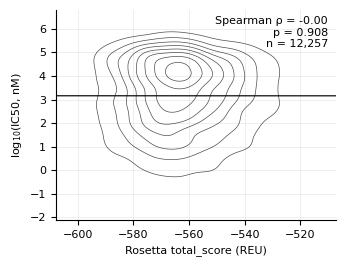

In [80]:
fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.7))
draw_score_vs_affinity(ax, ic50_df, rho_ic50, p_ic50,
                       x_label='Rosetta total_score (REU)',
                       y_label='log$_{10}$(IC50, nM)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_A_score_vs_ic50.png')
fig.savefig(FIG_DIR / 'panel_A_score_vs_ic50.pdf')
plt.show()

## Panel B: rosetta_best_score vs log₁₀(Kd)

Same structure as Panel A; Kd subset.

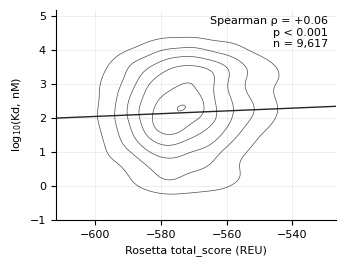

In [81]:
fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.7))
draw_score_vs_affinity(ax, kd_df, rho_kd, p_kd,
                       x_label='Rosetta total_score (REU)',
                       y_label='log$_{10}$(Kd, nM)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_B_score_vs_kd.png')
fig.savefig(FIG_DIR / 'panel_B_score_vs_kd.pdf')
plt.show()

## Panel C: Per-allele Spearman ρ distribution

Open circles, individual alleles; filled circles, p < 0.05. Median ρ marked as horizontal bar. Notable alleles labeled per the manuscript (HLA-A*68:01, A*30:02, A*23:01 positive standouts in IC50; HLA-B*27:05 the lone negative in Kd).

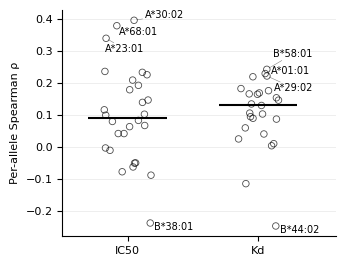

In [84]:
# Label top 3 positive + lowest, restricted to alleles with n ≥ 50
ic50_labels = pick_outlier_labels(ic50_alleles, top_pos=3, top_neg=1)
kd_labels   = pick_outlier_labels(kd_alleles,   top_pos=3, top_neg=1)
labels_by_metric = {'IC50': ic50_labels, 'Kd': kd_labels}

from adjustText import adjust_text

def draw_per_allele(ax, ic50_a, kd_a, labels_by_metric=None, jitter_seed=0):
    if labels_by_metric is None:
        labels_by_metric = {
            'IC50': pick_outlier_labels(ic50_a, top_pos=3, top_neg=1),
            'Kd':   pick_outlier_labels(kd_a,   top_pos=3, top_neg=1),
        }
    rng = np.random.default_rng(jitter_seed)
    positions = {'IC50': 0, 'Kd': 1}
    JITTER_W = 0.18
    
    all_texts = []   # collect for adjust_text

    for metric, frame in (('IC50', ic50_a), ('Kd', kd_a)):
        x_pos = positions[metric]
        jitter = rng.uniform(-JITTER_W, JITTER_W, len(frame))
        rho_vals = frame['rho'].values
        x_vals = x_pos + jitter

        ax.scatter(x_vals, rho_vals,
                   facecolor='none', edgecolor='black',
                   s=22, linewidth=0.6, alpha=0.7, zorder=3)

        med = frame['rho'].median()
        ax.hlines(med, x_pos - 0.3, x_pos + 0.3,
                  color='black', linewidth=1.5, zorder=5)

        # Collect labels — placement is just initial, adjust_text moves them
        targets = labels_by_metric[metric]
        for i, row in frame.iterrows():
            if row['allele'] in targets:
                t = ax.text(x_vals[i], row['rho'],
                            row['allele'].replace('HLA-', ''),
                            fontsize=FONT_SIZE - 1,
                            va='center', ha='left',
                            zorder=6)
                all_texts.append(t)

    #ax.axhline(0, color=ACCENT_RED, linestyle='--',
    #           linewidth=0.8, alpha=0.85, zorder=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IC50', 'Kd'])
    ax.set_xlim(-0.5, 1.6)
    ax.set_ylabel('Per-allele Spearman ρ')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.minorticks_off()
    ax.yaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

    # Resolve overlaps — draws leader lines for moved labels
    if all_texts:
        adjust_text(all_texts, ax=ax,
                    arrowprops=dict(arrowstyle='-', color='grey',
                                    lw=0.4, shrinkA=2, shrinkB=2),
                    expand=(1.2, 1.4),
                    only_move={'text': 'xy', 'static': 'xy', 'explode': 'xy', 'pull': 'xy'})

fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.7))
draw_per_allele(ax, ic50_alleles, kd_alleles)
fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_C_per_allele_rho.png')
fig.savefig(FIG_DIR / 'panel_C_per_allele_rho.pdf')
plt.show()

## Combined figure

Three panels in a single row at COL2_WIDTH for the publication-ready figure.

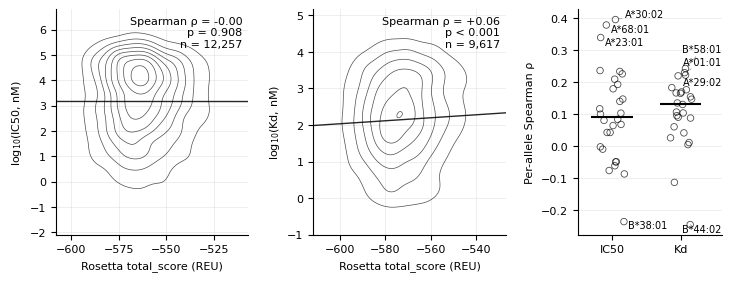

In [86]:
fig = plt.figure(figsize=(COL2_WIDTH, 2.7), constrained_layout=True)
axes = fig.subplots(1, 3, gridspec_kw={'width_ratios': [2, 2, 1.5], 'wspace': 0.08})

draw_score_vs_affinity(axes[0], ic50_df, rho_ic50, p_ic50,
                       x_label='Rosetta total_score (REU)',
                       y_label='log$_{10}$(IC50, nM)')

draw_score_vs_affinity(axes[1], kd_df, rho_kd, p_kd,
                       x_label='Rosetta total_score (REU)',
                       y_label='log$_{10}$(Kd, nM)')

draw_per_allele(axes[2], ic50_alleles, kd_alleles, labels_by_metric)

fig.savefig(FIG_DIR / 'figure3_combined.png', dpi=1200)
fig.savefig(FIG_DIR / 'figure3_combined.pdf')
plt.show()

## Summary

Panel files in `figure3_panels/`:

- `panel_A_score_vs_ic50.{png,pdf}` — pooled IC50 contour
- `panel_B_score_vs_kd.{png,pdf}` — pooled Kd contour
- `panel_C_per_allele_rho.{png,pdf}` — per-allele Spearman ρ strip plot
- `figure3_combined.{png,pdf}` — three-panel composite for the paper

**Combining in Keynote:**

1. New slide, set custom size 519 pt × 200 pt (= 183 × 70 mm, double-column figure, single-row).
2. Drop `figure3_combined.png`, or compose panels A/B/C individually for tighter alignment.
3. Add panel letters (A, B, C) as separate text boxes, Helvetica/Arial Bold 14 pt, upper-left of each panel.
4. Export at 300 dpi PNG.

**Things you may want to adjust:**

- `MIN_N` (minimum sample size per allele) — currently 10. The manuscript reports 28 IC50 alleles and 25 Kd alleles, which may imply a different threshold; check the output of the per-allele cell.
- Number of contour levels (`n_contours` in the helper) — 8 by default; reduce to 5–6 for less busy contours.
- Notable allele labels in Panel C — `NOTABLE_LABELS` set is editable. If labels collide with dots, increase `xytext` offset.